In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.base import clone

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

In [2]:
pd.set_option('display.max_columns', None)
X_train = pd.read_csv('data/train075_no_apache.csv')
y_train = pd.read_csv('data/Ytrain075.csv').squeeze()
X_test = pd.read_csv('data/test_no_apache.csv').squeeze()
y_test = pd.read_csv('data/y_test.csv')
X_train.head(5)

,age,elective_surgery,gender,height,pre_icu_los_days,weight,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,d1_heartrate_range,d1_mbp_range,d1_resprate_range,d1_spo2_range,d1_sysbp_range,d1_temp_range,h1_diasbp_range,h1_heartrate_range,h1_mbp_range,h1_resprate_range,h1_spo2_range,h1_sysbp_range,h1_temp_range,d1_albumin_range,d1_bilirubin_range,d1_bun_range,d1_calcium_range,d1_creatinine_range,d1_glucose_range,d1_hco3_range,d1_hemaglobin_range,d1_platelets_range,d1_potassium_range,d1_sodium_range,d1_wbc_range,h1_glucose_range
0,74.0,0.0,1.0,178.0,0.259722,70.4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0,33.0,17.0,7.0,40.0,0.7,17.0,16.0,16.0,3.0,5.0,19.0,0.1,0.1,0.1,0.0,0.0,0.00,0.0,0.0,4.6,15.0,0.0,0.0,0.7,6.0
1,66.0,0.0,0.0,162.0,0.052778,58.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,28.0,51.0,9.0,39.0,1.3,9.0,8.0,5.0,16.0,2.0,7.0,0.0,0.1,0.1,0.0,0.0,0.00,0.0,0.0,0.5,10.0,1.5,0.0,0.9,6.0
2,64.0,0.0,0.0,170.2,0.355556,113.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,20.0,95.0,16.0,5.0,109.0,0.5,26.0,14.0,40.0,8.0,4.0,29.0,0.0,0.0,0.0,0.0,0.0,0.00,118.0,0.0,0.5,10.0,0.0,0.0,0.9,6.0
3,77.0,0.0,1.0,182.9,0.035417,86.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,21.0,22.0,13.0,6.0,52.0,0.2,11.0,7.0,10.0,6.0,0.0,24.0,0.0,0.1,0.1,1.0,0.2,0.05,136.0,1.0,0.5,10.0,0.0,1.0,0.9,6.0
4,42.0,0.0,1.0,170.1,0.147917,85.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,34.0,26.0,12.0,2.0,29.0,0.5,19.0,17.0,18.0,9.0,2.0,23.0,0.1,0.1,0.1,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0


In [3]:
rf = RandomForestClassifier(random_state = 24)

rf.fit(X_train, y_train)

y_proba = rf.predict_proba(X_test)[:,1]
y_pred = rf.predict(X_test)

Accuracy: 91.50%
Recall: 17.79%
Precision: 55.20%
F1: 26.91%


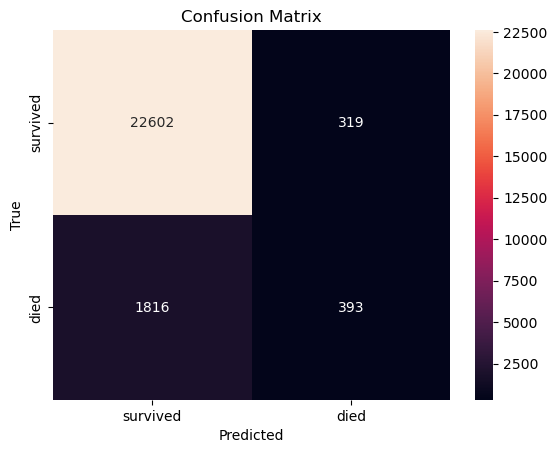

In [4]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy: %.2f%%' % (accuracy * 100.0))
print('Recall: %.2f%%' % (recall * 100.0))
print('Precision: %.2f%%' % (precision * 100.0))
print('F1: %.2f%%' % (f1 * 100.0))

matrix = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(matrix, annot = True, fmt = 'g', ax = ax);

ax.set_xlabel('Predicted');
ax.set_ylabel('True');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['survived', 'died']);
ax.yaxis.set_ticklabels(['survived', 'died']);

In [5]:
matrix

array([[22602,   319],
       [ 1816,   393]])

AUC: 0.8131768912249209


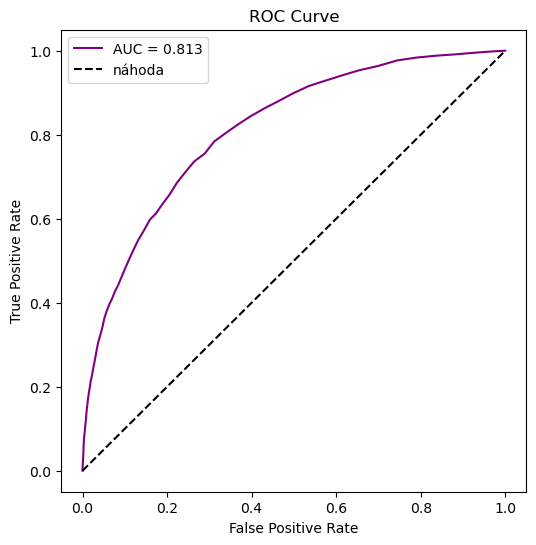

In [6]:
auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color = 'purple')
plt.plot([0,1], [0,1], 'k--', label='náhoda')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

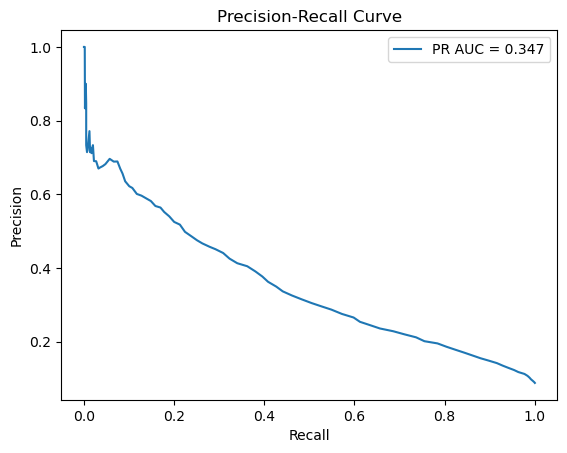

In [7]:
pr_auc = average_precision_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()